<a href="https://colab.research.google.com/github/LucianoBV/Procesamiento-del-habla/blob/main/TP2_webscrapping_preprocesamiento.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TP2 PROCESAMIENTO DEL HABLA

**Luciano Vargas.**


* Resolver las consignas comentando el código fuente, indicando desde dónde fue extraido o generado.

* Explicar y justificar cada paso realizado.

* Publique enlace público a su notebook en google colab y también enlace a su repositorio github de la materia.


### Entrega de los ejercicios

1. Crea un repositorio GitHub público dedicado a esta materia.
2. Sube tus notebooks de resolución para cada desafío allí.
3. Por cada desafío utilizaremos un sólo notebook.
4. Debes entregar tu TP en el foro correspondiente, siguiendo las instrucciones que allí indica.




## EJERCICIO CONSIGNA

* Cree una nube de palabras de un texto en español.

* Dicho texto puede ser descargado de Internet (webscrapping) o extraído del dataset de alguna librería.

* Puede usar cualquier libreria o herramienta para obtener el texto de su interés.

* En este notebook explica el paso a paso del proceso.



## 1- Webscrapping

Extrae un texto de Internet de una sóla página web usando alguna de las técnicas de webscrapping vistas en clase. Busca el discurso de alguna persona quien te inspire o haya dado una charla motivadora.

No puedes repetir ni usar ni el mismo texto ni la misma web que otra persona quien ya entregó en el foro.

Abajo añade los bloques de código y texto necesarios. Explica paso a paso como descargaste el texto de tu interés.


In [119]:
! pip install requests beautifulsoup4 html5lib
import requests
from bs4 import BeautifulSoup

## Webscraping de un discurso motivador

Elegí el discurso **“I Have a Dream”** de Martin Luther King Jr., porque transmite un mensaje de igualdad, justicia y esperanza.

La página utilizada fue:


Se utiliza requests para descargar el HTML de la página.  
El header User-Agent evita el error 403 simulando un navegador.
Si el código devuelve **200**, significa que la página se descargó correctamente.

In [120]:
url = "https://www.marxists.org/espanol/king/1963/agosto28.htm"

headers = {
    "User-Agent": "Mozilla/5.0"
}

respuesta = requests.get(url, headers=headers)
print(respuesta.status_code)

200


Se usa BeautifulSoup para procesar el HTML y extraer los párrafos.  
El texto completo del discurso queda almacenado en la variable texto.

In [121]:
sopa = BeautifulSoup(respuesta.text, "html.parser")

parrafos = sopa.find_all("p")

texto = ""

for p in parrafos:
    texto += p.get_text(strip=True) + "\n"

print(texto[:3000])


Pronunciado:El 28 de agosto de 1963 delante del
monumento a Abraham Lincoln en Washington, DC, durante una histórica manifestación de más
de 200,000 en pro de los derechos civiles para los negros en los EE.UU.Versión al castellano:No consta.Versión digital:Wikisource
en Español, 2006.Esta edición:Marxists Internet Archive, septiembre
de  2006.Derechos:El contenido está disponible bajo los términos de
laGNU Free Documentation License.
Estoy orgulloso de reunirme con ustedes hoy, en la que será ante la historia la mayor manifestación por la libertad en la historia de nuestro país.Hace cien años, un gran estadounidense, cuya simbólica sombra nos cobija hoy, firmó la Proclama de la emancipación. Este trascendental decreto significó como un gran rayo de luz y de esperanza para millones de esclavos negros, chamuscados en las llamas de una marchita injusticia. Llegó como un precioso amanecer al final de una larga noche de cautiverio. Pero, cien años después, el negro aún no es libre; cien añ

In [122]:
print("Cantidad de caracteres:", len(texto))
print("Cantidad de palabras:", len(texto.split()))

Cantidad de caracteres: 37218
Cantidad de palabras: 6249


Con este código se descargó el HTML de la página, se procesó con **BeautifulSoup** y luego se extrajeron los párrafos principales usando la etiqueta `<p>`.

La variable `texto` contiene el contenido extraído de la página web, que luego se puede usar para analizar palabras, stopwords, frecuencias y limpieza del texto.

## 2- Preprocesamiento

### 2.1 Muestra las stop words que tenga tu texto.

Se convierte el texto a minúsculas y se tokeniza.  
Luego se identifican las stopwords en español utilizando NLTK.

In [123]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Descargar recursos (solo la primera vez)
nltk.download('punkt')
nltk.download('stopwords')

# Pasar el texto a minúsculas
texto_lower = texto.lower()

# Tokenizar
tokens = word_tokenize(texto_lower, language='spanish')

# Obtener stopwords en español
stop_words = set(stopwords.words('spanish'))

# Filtrar las stopwords que aparecen en el texto
stopwords_en_texto = [palabra for palabra in tokens if palabra in stop_words]

# Eliminar duplicados (para no repetirlas)
stopwords_unicas = sorted(set(stopwords_en_texto))

# Mostrar TODAS las stopwords encontradas
print("Cantidad de stopwords encontradas:", len(stopwords_unicas))
print(stopwords_unicas)

Cantidad de stopwords encontradas: 91
['a', 'al', 'algo', 'algunos', 'ante', 'como', 'con', 'cual', 'cuando', 'de', 'del', 'desde', 'donde', 'durante', 'e', 'el', 'en', 'entre', 'era', 'es', 'ese', 'eso', 'esta', 'estado', 'estados', 'estamos', 'estas', 'este', 'esto', 'estoy', 'está', 'ha', 'habrá', 'habría', 'han', 'hasta', 'hay', 'haya', 'hemos', 'la', 'las', 'les', 'lo', 'los', 'mi', 'mis', 'muchos', 'más', 'míos', 'ni', 'no', 'nos', 'nuestra', 'nuestras', 'nuestro', 'nuestros', 'o', 'otra', 'para', 'pero', 'por', 'porque', 'que', 'quienes', 'qué', 'se', 'sentido', 'seremos', 'será', 'serán', 'sería', 'serían', 'sin', 'son', 'su', 'sus', 'también', 'tanto', 'te', 'tendrá', 'tendrán', 'tengo', 'tenían', 'todo', 'todos', 'tuyo', 'un', 'una', 'y', 'ya', 'yo']


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


### 2.2 Quita las stop-words, caracteres extraños del texto. Utiliza el texto restante para crear una nube de palabras. Usa la biblioteca worldcloud de python.

Se eliminan stopwords y caracteres no deseados, dejando solo palabras relevantes.

In [124]:
import re
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Unimos tokens que NO sean stopwords y que sean palabras
tokens_limpios = []

for palabra in tokens:
    if palabra not in stop_words and palabra.isalpha():
        tokens_limpios.append(palabra)

# Unimos nuevamente las palabras limpias en un solo texto
texto_limpio = " ".join(tokens_limpios)

# Eliminamos caracteres extraños adicionales, dejando solo letras y espacios
texto_limpio = re.sub(r"[^a-záéíóúñü\s]", "", texto_limpio)

print(texto_limpio[:1000])

pronunciado agosto delante monumento abraham lincoln washington dc histórica manifestación pro derechos civiles negros castellano digital wikisource español edición marxists internet archive septiembre contenido disponible bajo términos lagnu free documentation license orgulloso reunirme ustedes hoy historia mayor manifestación libertad historia cien años gran estadounidense cuya simbólica sombra cobija hoy firmó proclama emancipación trascendental decreto significó gran rayo luz esperanza millones esclavos negros chamuscados llamas marchita injusticia llegó precioso amanecer final larga noche cautiverio cien años después negro aún libre cien años después vida negro aún tristemente lacerada esposas segregación cadenas discriminación cien años después negro vive isla solitaria medio inmenso océano prosperidad material cien años después negro todavía languidece esquinas sociedad estadounidense encuentra desterrado propia hoy venido aquí dramatizar condición vergonzosa cierto venido capit

La nube de palabras permite visualizar las palabras más frecuentes del discurso.

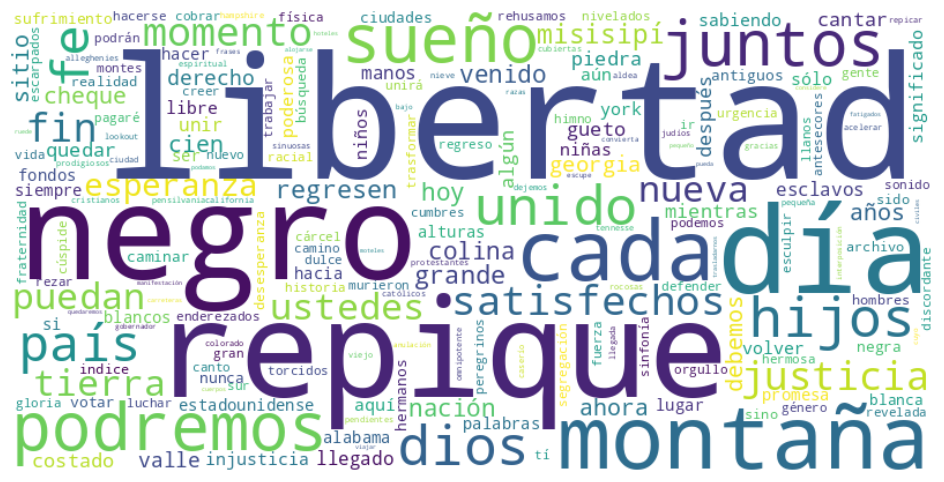

In [125]:
# Crear la nube de palabras
nube = WordCloud(
    width=800,
    height=400,
    background_color="white",
    collocations=False
).generate(texto_limpio)

# Mostrar la nube
plt.figure(figsize=(12, 6))
plt.imshow(nube, interpolation="bilinear")
plt.axis("off")
plt.show()

### 2.3 Usando el texto que conseguiste en el punto 1).



#### 2.3.1 Limpia y preprocesa el texto, descomponelo en oraciones, arma una matriz documento-vocabulario.


In [126]:
import pandas as pd
import nltk

from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer

nltk.download("punkt")
nltk.download("stopwords")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

Se divide el texto en oraciones, que serán consideradas como documentos.

In [127]:
# Lista de stopwords en español
stop_words = set(stopwords.words("spanish"))

# Separar el texto original en oraciones
oraciones = sent_tokenize(texto, language="spanish")

print("Cantidad de oraciones encontradas:", len(oraciones))
print(oraciones)

Cantidad de oraciones encontradas: 262
['\nPronunciado:El 28 de agosto de 1963 delante del\nmonumento a Abraham Lincoln en Washington, DC, durante una histórica manifestación de más\nde 200,000 en pro de los derechos civiles para los negros en los EE.UU.Versión al castellano:No consta.Versión digital:Wikisource\nen Español, 2006.Esta edición:Marxists Internet Archive, septiembre\nde\xa0 2006.Derechos:El contenido está disponible bajo los términos de\nlaGNU Free Documentation License.', 'Estoy orgulloso de reunirme con ustedes hoy, en la que será ante la historia la mayor manifestación por la libertad en la historia de nuestro país.Hace cien años, un gran estadounidense, cuya simbólica sombra nos cobija hoy, firmó la Proclama de la emancipación.', 'Este trascendental decreto significó como un gran rayo de luz y de esperanza para millones de esclavos negros, chamuscados en las llamas de una marchita injusticia.', 'Llegó como un precioso amanecer al final de una larga noche de cautiverio.

Se limpia cada oración eliminando ruido, stopwords y palabras irrelevantes.

In [128]:
def limpiar_texto(oracion):
    # Pasar a minúsculas
    oracion = oracion.lower()

    # Eliminar caracteres extraños, números y signos
    oracion = re.sub(r"[^a-záéíóúñü\s]", " ", oracion)

    # Tokenizar la oración
    palabras = word_tokenize(oracion, language="spanish")

    # Quitar stopwords y palabras muy cortas
    palabras_limpias = [
        palabra for palabra in palabras
        if palabra not in stop_words and len(palabra) > 2
    ]

    # Volver a unir las palabras limpias
    return " ".join(palabras_limpias)

In [129]:
# Aplicar la limpieza a cada oración
oraciones_limpias = [limpiar_texto(oracion) for oracion in oraciones]

# Eliminar oraciones que hayan quedado vacías
oraciones_limpias = [oracion for oracion in oraciones_limpias if oracion.strip() != ""]

print("Cantidad de oraciones limpias:", len(oraciones_limpias))
print(oraciones_limpias[:5])

Cantidad de oraciones limpias: 262
['pronunciado agosto delante monumento abraham lincoln washington histórica manifestación pro derechos civiles negros versión castellano consta versión digital wikisource español edición marxists internet archive septiembre derechos contenido disponible bajo términos lagnu free documentation license', 'orgulloso reunirme ustedes hoy historia mayor manifestación libertad historia país hace cien años gran estadounidense cuya simbólica sombra cobija hoy firmó proclama emancipación', 'trascendental decreto significó gran rayo luz esperanza millones esclavos negros chamuscados llamas marchita injusticia', 'llegó precioso amanecer final larga noche cautiverio', 'cien años después negro aún libre cien años después vida negro aún tristemente lacerada esposas segregación cadenas discriminación cien años después negro vive isla solitaria medio inmenso océano prosperidad material cien años después negro todavía languidece esquinas sociedad estadounidense encuent

Se construye la matriz documento-vocabulario, donde cada fila es una oración y cada columna una palabra.

In [130]:
# Crear el vectorizador
vectorizador = CountVectorizer()

# Crear la matriz documento-vocabulario
matriz_documento_vocabulario = vectorizador.fit_transform(oraciones_limpias)

# Convertir la matriz a DataFrame para verla mejor
df_matriz = pd.DataFrame(
    matriz_documento_vocabulario.toarray(),
    columns=vectorizador.get_feature_names_out()
)

df_matriz.head()

,abraham,acelerar,actos,adelante,afirmamos,agosto,agua,aguarda,ahora,alabama,...,vigorizante,violencia,vive,vivirá,vivirán,volver,votar,washington,wikisource,york
0,1,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,1,1,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0


In [131]:
print("Tamaño de la matriz:", df_matriz.shape)

Tamaño de la matriz: (262, 504)



#### 2.3.2 Determina la longitud de tu vocabulario.

In [132]:
# Obtener el vocabulario desde el vectorizador
vocabulario = vectorizador.get_feature_names_out()

# Calcular su longitud
longitud_vocabulario = len(vocabulario)

print("Longitud del vocabulario:", longitud_vocabulario)

Longitud del vocabulario: 504



#### 2.3.3. Aplica TF-IDF a tu matriz documento-vocabulario

TF-IDF permite ponderar la importancia de cada palabra en cada oración.

In [133]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

# Crear el vectorizador TF-IDF
vectorizador_tfidf = TfidfVectorizer()

# Aplicar TF-IDF sobre las oraciones limpias
matriz_tfidf = vectorizador_tfidf.fit_transform(oraciones_limpias)

# Convertir la matriz TF-IDF a DataFrame
df_tfidf = pd.DataFrame(
    matriz_tfidf.toarray(),
    columns=vectorizador_tfidf.get_feature_names_out()
)

df_tfidf.head()

,abraham,acelerar,actos,adelante,afirmamos,agosto,agua,aguarda,ahora,alabama,...,vigorizante,violencia,vive,vivirá,vivirán,volver,votar,washington,wikisource,york
0,0.169782,0.0,0.0,0.0,0.0,0.169782,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.169782,0.169782,0.0
1,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0
2,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0
3,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0
4,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.110351,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0


In [134]:
print("Cantidad de documentos (oraciones):", df_tfidf.shape[0])
print("Tamaño del vocabulario:", df_tfidf.shape[1])
print("Tamaño total de la matriz:", df_tfidf.shape)

Cantidad de documentos (oraciones): 262
Tamaño del vocabulario: 504
Tamaño total de la matriz: (262, 504)


Explica el formato de tu matriz resultante: documentos, vocabulario, tamaño. Brinda tus conclusiones.

### 2.6 Explicación de la matriz TF-IDF y conclusiones

#### Formato de la matriz

La matriz TF-IDF obtenida tiene la siguiente estructura:

- **Filas (documentos):** cada fila representa una oración del discurso previamente limpiada.  
- **Columnas (vocabulario):** cada columna corresponde a una palabra única del vocabulario generado luego del preprocesamiento.  
- **Valores:** cada celda contiene el peso TF-IDF de una palabra en una oración, es decir, qué tan importante es esa palabra dentro de ese documento en relación con todo el corpus.




# Conclusiones

Agregue aquí sus conclusiones sobre este trabajo práctico. Puede ser también parte del texto que posteará en el foro.

Conclusiones:

La matriz TF-IDF permite representar el texto de forma numérica, lo cual es fundamental para aplicar técnicas de análisis de datos o machine learning.
A diferencia de la matriz documento-vocabulario simple (conteo), TF-IDF da más importancia a las palabras relevantes y reduce el peso de las palabras muy frecuentes.
En este discurso, las palabras más importantes suelen estar relacionadas con conceptos como igualdad, libertad, justicia y derechos.
El preprocesamiento (eliminación de stopwords y limpieza) fue clave para mejorar la calidad del vocabulario y evitar ruido en los datos.
Este tipo de representación es muy útil para tareas como clasificación de textos, análisis de sentimientos o detección de temas.


# Anexo, código de ejemplo del uso de wordcloud

Instalar e importar la librería

In [135]:
# instalar wordcloud
!pip install wordcloud


In [136]:

# Importar librerías
from wordcloud import WordCloud
import matplotlib.pyplot as plt


In [137]:

# Texto de ejemplo
text = "Este es un texto de ejemplo para crear una nube de palabras usando word cloud. Puedes reemplazar este texto utilizando tu propio texto."

# Crear un objeto WordCloud
wordcloud = WordCloud(width=800, height=400, background_color="white").generate(text)


Mostramos la imagen generada

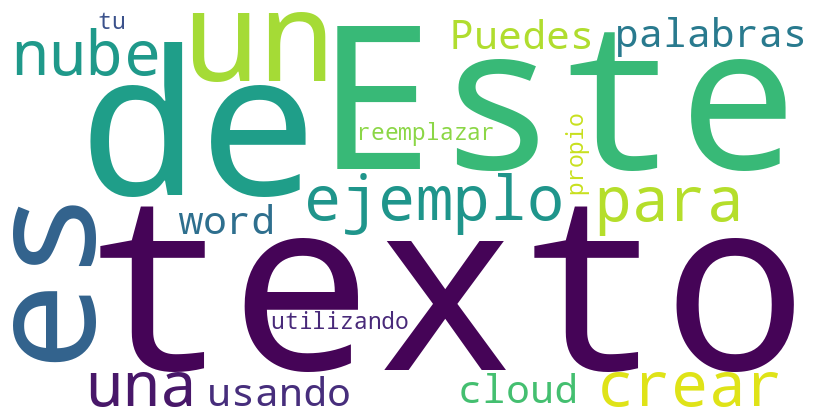

In [138]:

# mostramos la imagen generada
plt.figure(figsize=(8, 8), facecolor=None)
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad=0)
plt.show()

Modificamos el ejemplo anterior agregando palabras en español que no queremos que considere para crear la nube de palabras. Estas son las stop_words



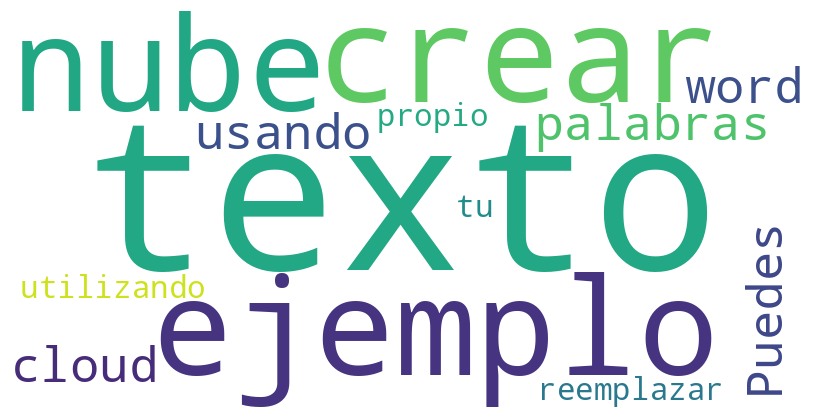

In [139]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

# Texto de ejemplo
text = "Este es un texto de ejemplo para crear una nube de palabras usando word cloud. Puedes reemplazar este texto utilizando tu propio texto."

# Definir stopwords en español
stopwords_es = set(STOPWORDS)
stopwords_es.update(["con", "que", "los", "para", "un", "una", "el", "la", "en", "y", "o", "de", "a", "se", "es", "al", "como", "por", "no", "su", "más", "pero", "si", "este", "esta", "eso", "esa", "todo", "todos", "todas", "cada", "cual", "cualquier", "algo", "alguna", "algún", "ningún", "ninguna", "ninguno", "otro", "otros", "otras", "sobre", "entre", "durante", "desde", "hasta", "también", "así", "mismo", "misma", "mismo", "misma", "tan", "tanto", "tanta", "muy", "poco", "poca", "poco", "nada", "solo", "sola", "solo", "sola", "siempre", "nunca", "jamás", "casi", "aproximadamente", "cerca", "lejos", "antes", "después", "ahora", "hoy", "ayer", "mañana", "luego", "mientras", "mientras tanto", "después de", "antes de", "durante", "sin", "aunque", "a pesar de", "debido a", "gracias a", "por qué", "cómo", "dónde", "cuándo", "quién", "qué", "cuál"])

# Crear un objeto WordCloud con stopwords en español
wordcloud = WordCloud(width=800, height=400, background_color="white", stopwords=stopwords_es).generate(text)

# Mostramos la imagen generada
plt.figure(figsize=(8, 8), facecolor=None)
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad=0)
plt.show()
